In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Source : reseau Sentinelles (INSERM, Sorbonne Universite), syndromes grippaux, France entiere
# https://www.sentiweb.fr/datasets/all/inc-3-PAY.csv  (telecharge le 09/10/2026)
s = pd.read_csv("data/externe/sentinelles_syndromes_grippaux.csv", comment="#", encoding="latin-1")
s["date_fin_semaine"] = pd.to_datetime(s["week"].astype(str) + "7", format="%G%V%u")
s["grippe"] = pd.to_numeric(s["inc100"], errors="coerce")   # cas pour 100 000 habitants
s = s[["date_fin_semaine", "grippe"]]
display(s.head())


,date_fin_semaine,grippe
0,2026-10-04,102.0
1,2026-09-27,89.0
2,2026-09-20,77.0
3,2026-09-13,55.0
4,2026-09-06,38.0


In [10]:
x["forte_grippe"] = x["grippe"] >= 150      # seuil choisi par nous : 51 semaines sur 300
comp = x.groupby("forte_grippe")[groupes].mean().T
comp.columns = ["semaine_normale", "semaine_forte_grippe"]
comp["ecart_%"] = (100 * (comp["semaine_forte_grippe"] / comp["semaine_normale"] - 1)).round(0)
display(comp.round(1))

,semaine_normale,semaine_forte_grippe,ecart_%
AINS acétiques (M01AB),35.6,36.0,1.0
AINS propioniques (M01AE),26.5,33.6,27.0
Aspirine et dérivés (N02BA),26.5,30.9,17.0
Paracétamol (N02BE),197.6,287.8,46.0
Anxiolytiques (N05B),61.1,65.4,7.0
Somnifères (N05C),4.1,4.3,3.0
Antiasthmatiques (R03),36.3,52.3,44.0
Antihistaminiques (R06),22.1,12.7,-43.0


In [11]:
w = pd.read_csv("data/clean/ventes_hebdo.csv", encoding="utf-8-sig", parse_dates=["date_fin_semaine"])
w = w[w["semaine_complete"]]
groupes = [c for c in w.columns if c.endswith(")")]
x = w.merge(s, on="date_fin_semaine", how="left")
print(len(x), "semaines ;", x["grippe"].isna().sum(), "sans donnee grippe")

300 semaines ; 0 sans donnee grippe


In [12]:
corr = x[groupes].corrwith(x["grippe"])
tableau = pd.DataFrame({"correlation": corr.round(2),
                        "part_expliquee_%": (100 * corr**2).round(0)})
display(tableau.sort_values("correlation", ascending=False))

,correlation,part_expliquee_%
Paracétamol (N02BE),0.42,17.0
AINS propioniques (M01AE),0.39,15.0
Antiasthmatiques (R03),0.29,8.0
Aspirine et dérivés (N02BA),0.24,6.0
Anxiolytiques (N05B),0.09,1.0
Somnifères (N05C),0.03,0.0
AINS acétiques (M01AB),0.01,0.0
Antihistaminiques (R06),-0.32,10.0


In [13]:
x["forte_grippe"] = x["grippe"] >= 150      # seuil choisi par nous : 51 semaines sur 300
comp = x.groupby("forte_grippe")[groupes].mean().T
comp.columns = ["semaine_normale", "semaine_forte_grippe"]
comp["ecart_%"] = (100 * (comp["semaine_forte_grippe"] / comp["semaine_normale"] - 1)).round(0)
display(comp.round(1))

,semaine_normale,semaine_forte_grippe,ecart_%
AINS acétiques (M01AB),35.6,36.0,1.0
AINS propioniques (M01AE),26.5,33.6,27.0
Aspirine et dérivés (N02BA),26.5,30.9,17.0
Paracétamol (N02BE),197.6,287.8,46.0
Anxiolytiques (N05B),61.1,65.4,7.0
Somnifères (N05C),4.1,4.3,3.0
Antiasthmatiques (R03),36.3,52.3,44.0
Antihistaminiques (R06),22.1,12.7,-43.0


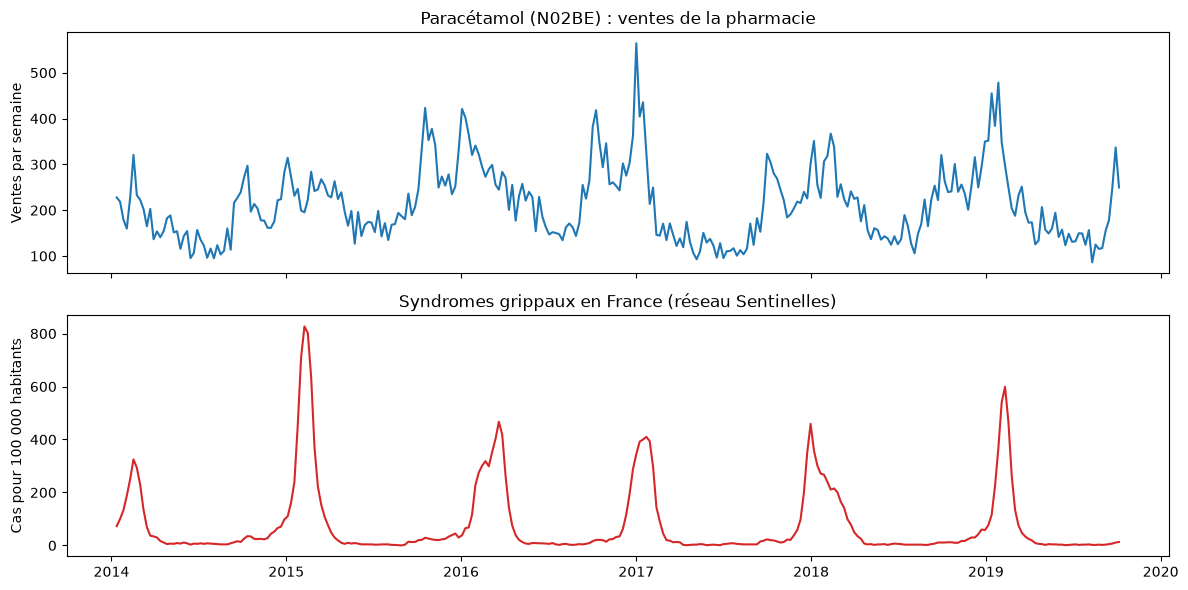

In [14]:
para = [g for g in groupes if "N02BE" in g][0]
fig, (haut, bas) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
haut.plot(x["date_fin_semaine"], x[para])
haut.set_ylabel("Ventes par semaine")
haut.set_title(f"{para} : ventes de la pharmacie")
bas.plot(x["date_fin_semaine"], x["grippe"], color="tab:red")
bas.set_ylabel("Cas pour 100 000 habitants")
bas.set_title("Syndromes grippaux en France (réseau Sentinelles)")
plt.tight_layout()
plt.show()